In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"

[2025年04月23日 18时19分53秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

AnnData object with n_obs × n_vars = 926 × 1128
    obs: 'c', 'milestone_color', 'milestone'
    var: 'feature_id', 'housekeeping'
    uns: 'cfe', 'pca', 'tsne', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'
    obsm: 'X_pca', 'X_tsne', 'milestone_network_emb'
    varm: 'PCs'
    layers: 'expression', 'counts'

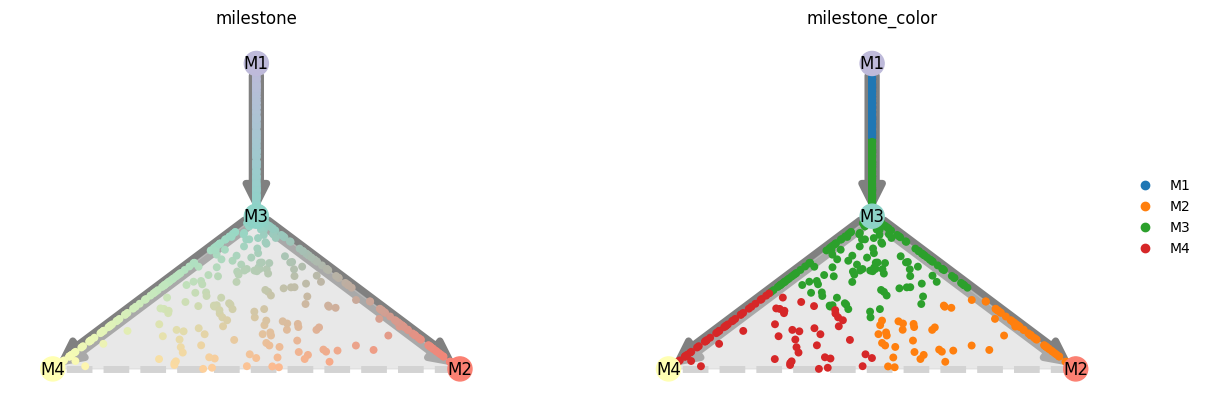

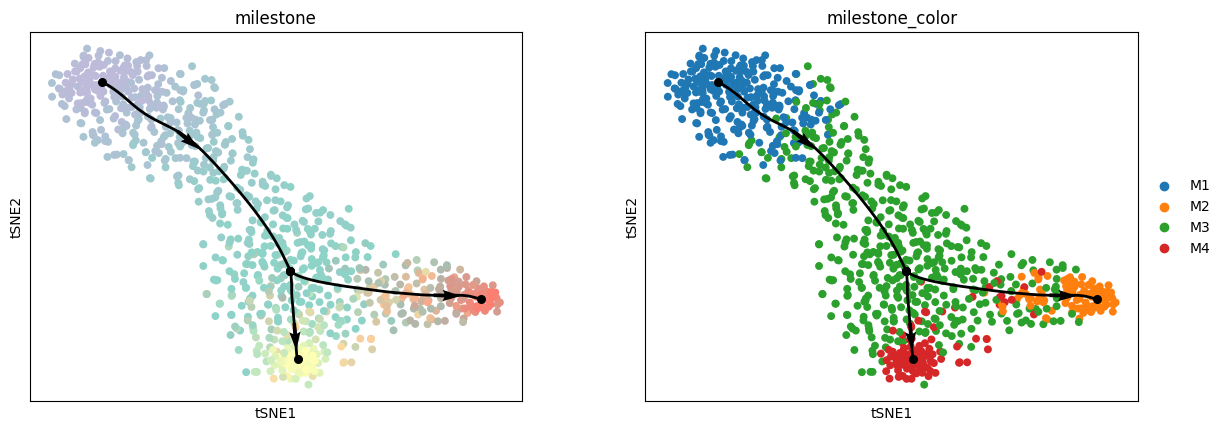

In [2]:
fadata = cfe.data.FateAnnData.read_dynverse_simulation_data()

cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color
sc.tl.tsne(fadata)

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis="tsne", color=cluster_key_list)
fadata

Method and plot

In [3]:
prior_information = {"start_id": "C1", "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.05}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["paga", "comp1", "angle", "state_comp", "cluster_mst", "projection_mst", "graph_mst"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

[2025年04月23日 18时20分06秒] INFO     Loaded function: <function cf_paga at 0x7879f4bd9b40> from                  
                                       /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_paga.py              
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x787944d4a260>                                                                   
Normalized count data: X.
Logarithmized X.


KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

## 指标

In [ ]:
parsed_model_name_list = fadata.get_all_model_name()
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list
# model_name_list = model_name_list[:-1] # TODO: 最后一个mst指标暂时会出错， 原因在于对于无向图的简化操作会报错

In [ ]:
metrics = cfe.metric.metrics
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
metric_id_list

In [ ]:
import pandas as pd


model_metric_dict = {}

for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(fadata, metrics=metric_id_list, now_model=model_name, ref_model="ref")
    model_metric_dict[model_name] = model_metric

df = pd.DataFrame(model_metric_dict).T
df